Thermalizing lattice...


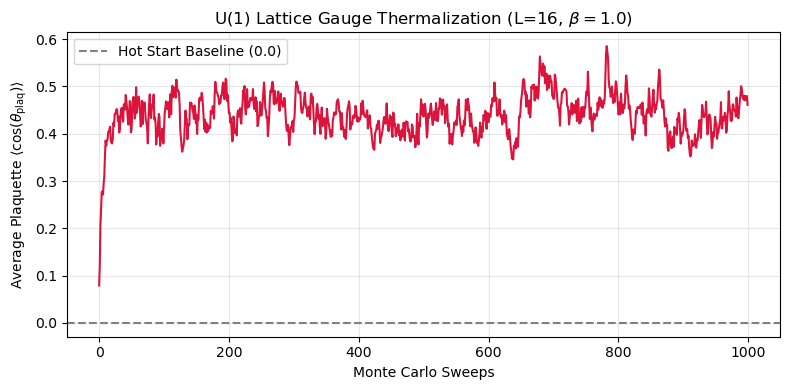

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
L = 16          # Grid size L x L
beta = 1.0      # Coupling constant
sweeps = 1000   # Number of Monte Carlo sweeps
epsilon = 0.5   # Update step size for proposed angles

# Initialize Hot Start (random angles in [-pi, pi))
theta = np.random.uniform(-np.pi, np.pi, size=(2, L, L))

def compute_plaquettes(theta):
    """Computes all 1x1 plaquette angles on an L x L periodic lattice."""
    theta_x = theta[0]
    theta_y = theta[1]
    
    # Correct axis shifts for periodic 2D grid
    theta_y_shift_x = np.roll(theta_y, shift=-1, axis=0) # (x+1, y)
    theta_x_shift_y = np.roll(theta_x, shift=-1, axis=1) # (x, y+1)
    
    return theta_x + theta_y_shift_x - theta_x_shift_y - theta_y

def sweep_metropolis(theta, beta, epsilon):
    """Performs one full Monte Carlo sweep across every link on the lattice."""
    for mu in range(2):
        for x in range(L):
            for y in range(L):
                # Propose a small shift delta
                old_val = theta[mu, x, y]
                delta = np.random.uniform(-epsilon, epsilon)
                new_val = old_val + delta
                
                # Compute local action change Delta S for affected plaquettes only
                # Link at (mu, x, y) affects exactly 2 plaquettes
                if mu == 0:  # x-link
                    # Plaquette 1 (above) and Plaquette 2 (below)
                    p1_old = theta[0, x, y] + theta[1, (x+1)%L, y] - theta[0, x, (y+1)%L] - theta[1, x, y]
                    p2_old = theta[0, x, (y-1)%L] + theta[1, (x+1)%L, (y-1)%L] - theta[0, x, y] - theta[1, x, (y-1)%L]
                    
                    theta[mu, x, y] = new_val
                    p1_new = theta[0, x, y] + theta[1, (x+1)%L, y] - theta[0, x, (y+1)%L] - theta[1, x, y]
                    p2_new = theta[0, x, (y-1)%L] + theta[1, (x+1)%L, (y-1)%L] - theta[0, x, y] - theta[1, x, (y-1)%L]
                else:       # y-link
                    p1_old = theta[0, x, y] + theta[1, (x+1)%L, y] - theta[0, x, (y+1)%L] - theta[1, x, y]
                    p2_old = theta[0, (x-1)%L, y] + theta[1, x, y] - theta[0, (x-1)%L, (y+1)%L] - theta[1, (x-1)%L, y]
                    
                    theta[mu, x, y] = new_val
                    p1_new = theta[0, x, y] + theta[1, (x+1)%L, y] - theta[0, x, (y+1)%L] - theta[1, x, y]
                    p2_new = theta[0, (x-1)%L, y] + theta[1, x, y] - theta[0, (x-1)%L, (y+1)%L] - theta[1, (x-1)%L, y]
                
                # Delta S = -beta * (cos(new) - cos(old))
                dS = -beta * ((np.cos(p1_new) + np.cos(p2_new)) - (np.cos(p1_old) + np.cos(p2_old)))
                
                # Metropolis Accept / Reject step
                if dS > 0 and np.random.rand() > np.exp(-dS):
                    theta[mu, x, y] = old_val # Reject: revert back

# 2. Main Thermalization Loop
history = []
print("Thermalizing lattice...")
for step in range(sweeps):
    sweep_metropolis(theta, beta, epsilon)
    avg_plaq = np.mean(np.cos(compute_plaquettes(theta)))
    history.append(avg_plaq)

# 3. Plot Thermalization Curve
plt.figure(figsize=(8, 4))
plt.plot(history, color='crimson', lw=1.5)
plt.axhline(0, color='gray', linestyle='--', label='Hot Start Baseline (0.0)')
plt.xlabel("Monte Carlo Sweeps")
plt.ylabel(r"Average Plaquette $\langle \cos(\theta_{\mathrm{plaq}}) \rangle$")
plt.title(f"U(1) Lattice Gauge Thermalization (L={L}, $\\beta={beta}$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



We have our wilson loop (per plaquette): $$W_{\mu\nu}(n) = W_\mu(n) W_\nu(n+\hat{\mu}) W_{-\mu}(n+\hat{\mu}+\hat{\nu})W_{-\nu}(n+\hat{\nu})  $$. If we choose $\hat{\nu} = a \hat{y}$ and $\hat{\mu} = a \hat{x}$ due to lattice spacing, we obtain, with $n \equiv (x,y)$, that $$ W_{\mu\nu}(x,y) = W_\mu(x,y) W_\nu(x+a,y) W_{-\mu}(x+a,y+a)W_{-\nu}(x,y+a)$$. The angle of the plaquette is $\theta_n + \theta_{n+\hat{\mu}} - \theta_{n + \hat{\mu} +\hat{\nu}} - \theta_{n+\hat{\nu}}$ The (change in) action is proportional to $\cos{\theta}$ since it is proportional to $\text{Re}(\mathbb{1} - {W_{\mu\nu}})$